# ResNet-18 CIFAR-10 Teacher vs Random Forest Students

Load saved probability artifacts for the CIFAR-10 test split and OOD datasets,
then compare teacher and random forest student outputs for the cross-entropy and logits
training objectives. Far-OOD groups MNIST and SVHN, while near-OOD corresponds
to CIFAR-100.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

sns.set_theme(style="darkgrid", context="notebook")

ROOT = Path.cwd()
if not (ROOT / "runs").exists():
    ROOT = ROOT.parent

SRC_PATH = ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from distill_ood_detection.evaluation.ood_scores import (
    absolute_max_probability_difference,
    logit_l2_distance,
    max_probability_difference,
    student_teacher_kl_divergence,
)

EXPERIMENT_NAME = "random_forest_student_resnet18_cifar10"
PROBABILITY_DIR = ROOT / "runs" / EXPERIMENT_NAME / "probabilities"
MANIFEST_PATH = PROBABILITY_DIR / "manifest.json"
CHECKPOINT = "best"

MODES = {
    "logits": "Random Forest Logits",
}
DATASETS = {
    "cifar10_test": "ID: CIFAR-10 test",
    "mnist_test": "Far-OOD: MNIST test",
    "svhn_test": "Far-OOD: SVHN test",
    "cifar100_test": "Near-OOD: CIFAR-100 test",
}
DATASET_GROUPS = {
    "cifar10_test": "ID",
    "mnist_test": "Far-OOD",
    "svhn_test": "Far-OOD",
    "cifar100_test": "Near-OOD",
}
DISTRIBUTION_ORDER = ["ID", "Far-OOD", "Near-OOD"]

MANIFEST_PATH


PosixPath('/Users/bsh2022/Projects/distill-ood-detection/runs/random_forest_student_resnet18_cifar10/probabilities/manifest.json')

In [2]:
with MANIFEST_PATH.open("r", encoding="utf-8") as handle:
    manifest = json.load(handle)

manifest["experiment_name"], manifest["checkpoint_selection"]


('random_forest_student_resnet18_cifar10', 'best')

In [3]:
def load_probability_artifact(path: str | Path) -> dict[str, object]:
    """Load one saved probability artifact on CPU."""

    artifact_path = Path(path)
    if not artifact_path.is_absolute():
        artifact_path = ROOT / artifact_path
    return torch.load(artifact_path, map_location="cpu", weights_only=False)


artifacts = []
for entry in manifest["artifacts"]:
    artifact = load_probability_artifact(entry["path"])
    artifacts.append({**artifact, **entry})

len(artifacts)


12

In [4]:
teacher_outputs = {
    artifact["dataset"]: artifact
    for artifact in artifacts
    if artifact["model"] == "teacher"
}

student_outputs = {
    (artifact["dataset"], artifact["mode"], artifact["checkpoint"]): artifact
    for artifact in artifacts
    if artifact["model"] == "student"
}

available_modes = sorted(
    {
        artifact["mode"]
        for artifact in artifacts
        if (
            artifact["model"] == "student"
            and artifact["checkpoint"] == CHECKPOINT
            and artifact["mode"] in MODES
        )
    },
    key=list(MODES).index,
)
available_datasets = sorted(
    teacher_outputs,
    key=list(DATASETS).index,
)

if not available_modes:
    raise ValueError(
        f"No student probability artifacts found for checkpoint={CHECKPOINT!r} in {MANIFEST_PATH}."
    )

MODE_ORDER = available_modes
DATASET_ORDER = [
    dataset_key
    for dataset_key in DATASETS
    if dataset_key in available_datasets
    and any(
        (dataset_key, mode_key, CHECKPOINT) in student_outputs
        for mode_key in MODE_ORDER
    )
]


def to_numpy(tensor: torch.Tensor) -> np.ndarray:
    """Move a tensor to CPU and convert it to a NumPy array."""

    return tensor.detach().cpu().numpy()


def build_comparison(dataset_key: str, mode_key: str) -> dict[str, np.ndarray]:
    """Assemble teacher/student scores for one dataset and training objective."""

    teacher = teacher_outputs[dataset_key]
    student = student_outputs[(dataset_key, mode_key, CHECKPOINT)]

    teacher_logits = to_numpy(teacher["logits"])
    student_logits = to_numpy(student["logits"])
    teacher_probs = to_numpy(teacher["probabilities"])
    student_probs = to_numpy(student["probabilities"])

    return {
        "teacher_max_probability": teacher_probs.max(axis=1),
        "student_max_probability": student_probs.max(axis=1),
        "max_probability_difference": max_probability_difference(
            teacher_probs,
            student_probs,
        ),
        "absolute_max_probability_difference": absolute_max_probability_difference(
            teacher_probs,
            student_probs,
        ),
        "student_teacher_kl_divergence": student_teacher_kl_divergence(
            teacher_probs,
            student_probs,
        ),
        "logit_l2_distance": logit_l2_distance(
            teacher_logits,
            student_logits,
        ),
    }


comparisons = {
    (mode_key, dataset_key): build_comparison(dataset_key, mode_key)
    for mode_key in MODE_ORDER
    for dataset_key in DATASET_ORDER
    if (dataset_key, mode_key, CHECKPOINT) in student_outputs
}


SCORE_LABELS = {
    "teacher_max_probability": "Teacher maximum probability",
    "student_max_probability": "Student maximum probability",
    "max_probability_difference": "max_proba_teacher - max_proba_student",
    "absolute_max_probability_difference": "abs(max_proba_teacher - max_proba_student)",
    "student_teacher_kl_divergence": "KL(teacher || student)",
    "logit_l2_distance": "L2 distance between centered teacher and student logits",
}
SCORE_TITLES = {
    "teacher_max_probability": "Teacher Maximum Probability",
    "student_max_probability": "Student Maximum Probability",
    "max_probability_difference": "Teacher-Student Maximum Probability Difference",
    "absolute_max_probability_difference": "Absolute Maximum Probability Difference",
    "student_teacher_kl_divergence": "Student-Teacher KL Divergence",
    "logit_l2_distance": "Teacher-Student Centered Logit L2 Distance",
}


def build_grouped_score_frame(score_key: str) -> pd.DataFrame:
    """Collect one score into a dataframe by training objective and dataset group."""

    score_frames = []
    for (mode_key, dataset_key), comparison in comparisons.items():
        score_frames.append(
            pd.DataFrame(
                {
                    "score": comparison[score_key],
                    "distribution": DATASET_GROUPS[dataset_key],
                    "dataset": DATASETS[dataset_key],
                    "mode": MODES[mode_key],
                }
            )
        )

    return pd.concat(score_frames, ignore_index=True)


score_frames = {
    score_key: build_grouped_score_frame(score_key)
    for score_key in SCORE_LABELS
}

{
    "available_modes": [MODES[mode_key] for mode_key in MODE_ORDER],
    "available_datasets": [DATASETS[dataset_key] for dataset_key in DATASET_ORDER],
    "score_rows": {
        score_key: len(frame)
        for score_key, frame in score_frames.items()
    },
}


{'available_modes': ['Random Forest Logits'],
 'available_datasets': ['ID: CIFAR-10 test',
  'Far-OOD: MNIST test',
  'Far-OOD: SVHN test',
  'Near-OOD: CIFAR-100 test'],
 'score_rows': {'teacher_max_probability': 56032,
  'student_max_probability': 56032,
  'max_probability_difference': 56032,
  'absolute_max_probability_difference': 56032,
  'student_teacher_kl_divergence': 56032,
  'logit_l2_distance': 56032}}

In [5]:
def make_axes_grid(
    figsize: tuple[int, int] | None = None,
) -> tuple[plt.Figure, np.ndarray]:
    """Create a grid with one subplot per available training objective."""

    mode_count = len(MODE_ORDER)
    ncols = mode_count
    nrows = int(np.ceil(mode_count / ncols))
    if figsize is None:
        figsize = (7 * ncols, 5 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[mode_count:]:
        ax.set_visible(False)
    return fig, axes


deep_palette = sns.color_palette("deep")
dark_palette = sns.color_palette("dark")
distribution_palette = {
    "ID": deep_palette[0],
    "Far-OOD": deep_palette[3],
    "Near-OOD": dark_palette[2],
}


def plot_score_histograms(
    score_key: str,
    *,
    bins: int | np.ndarray = 40,
    kde: bool = True,
) -> None:
    """Plot one score histogram per random forest training objective."""

    fig, axes = make_axes_grid()
    frame = score_frames[score_key]

    for axis_index, mode_key in enumerate(MODE_ORDER):
        ax = axes[axis_index]
        mode_name = MODES[mode_key]
        mode_frame = frame.loc[frame["mode"] == mode_name]

        sns.histplot(
            data=mode_frame,
            x="score",
            hue="distribution",
            hue_order=DISTRIBUTION_ORDER,
            palette=distribution_palette,
            bins=bins,
            kde=kde,
            stat="percent",
            common_norm=False,
            ax=ax,
        )
        ax.set_title(mode_name)
        ax.set_xlabel(SCORE_LABELS[score_key])
        ax.set_ylabel("Percent")
        legend = ax.get_legend()
        if legend is not None:
            legend.set_title("Dataset group")

    fig.suptitle(
        f"Histogram of {SCORE_TITLES[score_key]}",
        fontsize=13,
    )


## Maximum probability histograms

Teacher and student maximum probabilities are standard confidence-style OOD scores.


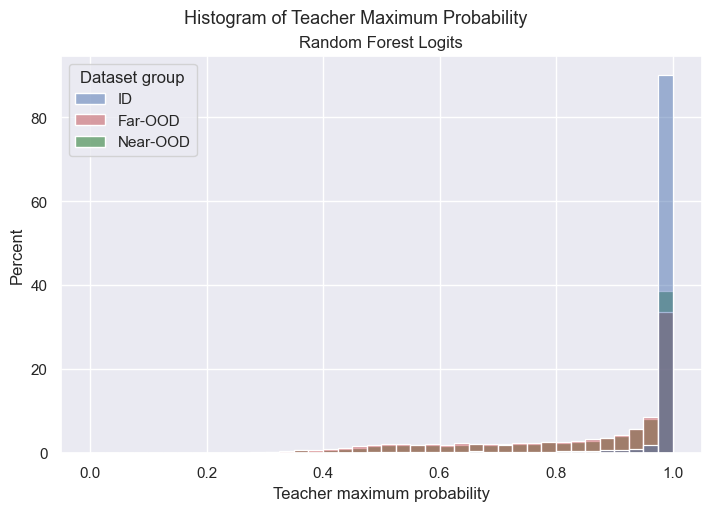

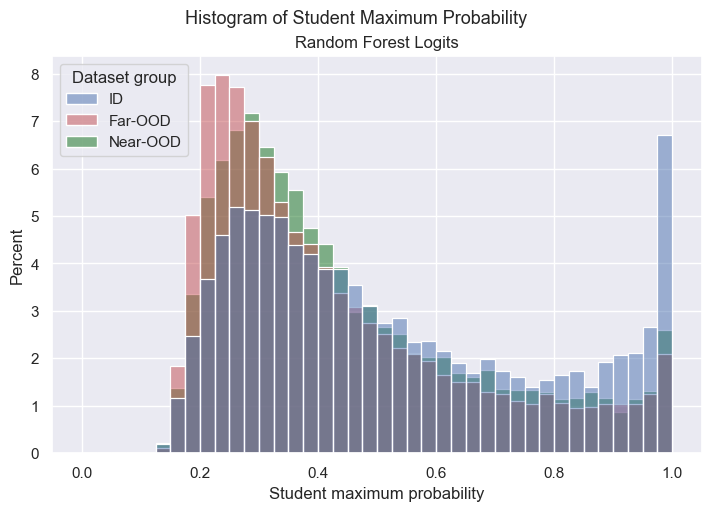

In [6]:
probability_bins = np.linspace(0.0, 1.0, 41)

plot_score_histograms(
    "teacher_max_probability",
    bins=probability_bins,
    kde=False,
)
plot_score_histograms(
    "student_max_probability",
    bins=probability_bins,
    kde=False,
)


## Teacher-student probability distance histograms


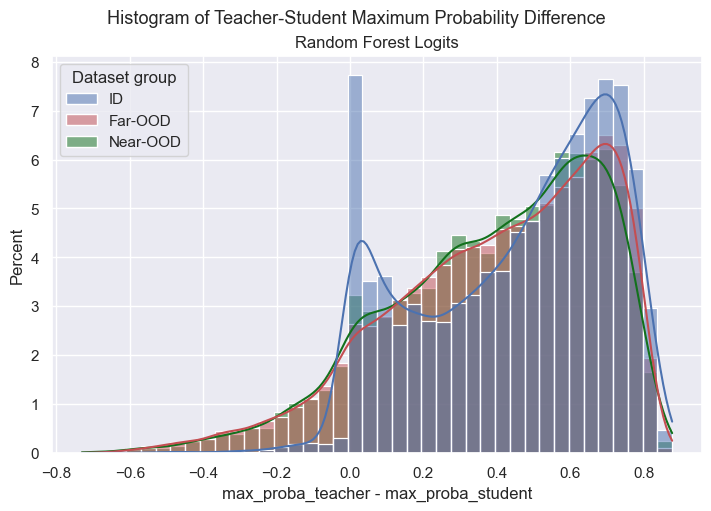

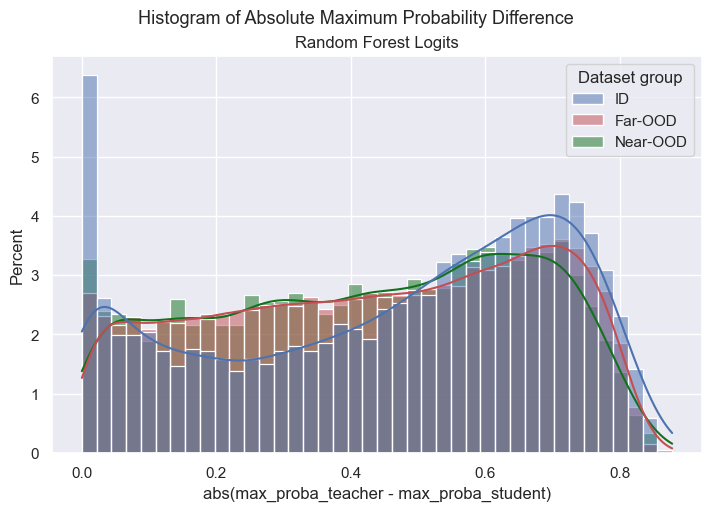

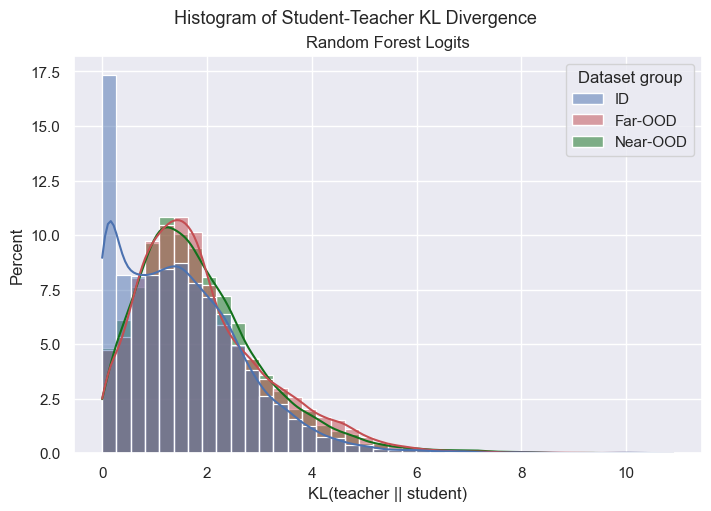

In [7]:
plot_score_histograms("max_probability_difference")
plot_score_histograms("absolute_max_probability_difference")
plot_score_histograms("student_teacher_kl_divergence")


## Teacher-student logit distance histograms


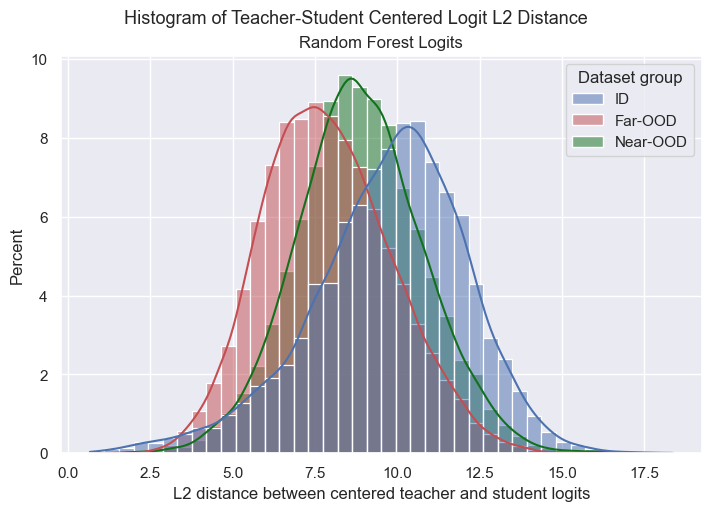

In [8]:
plot_score_histograms("logit_l2_distance")
